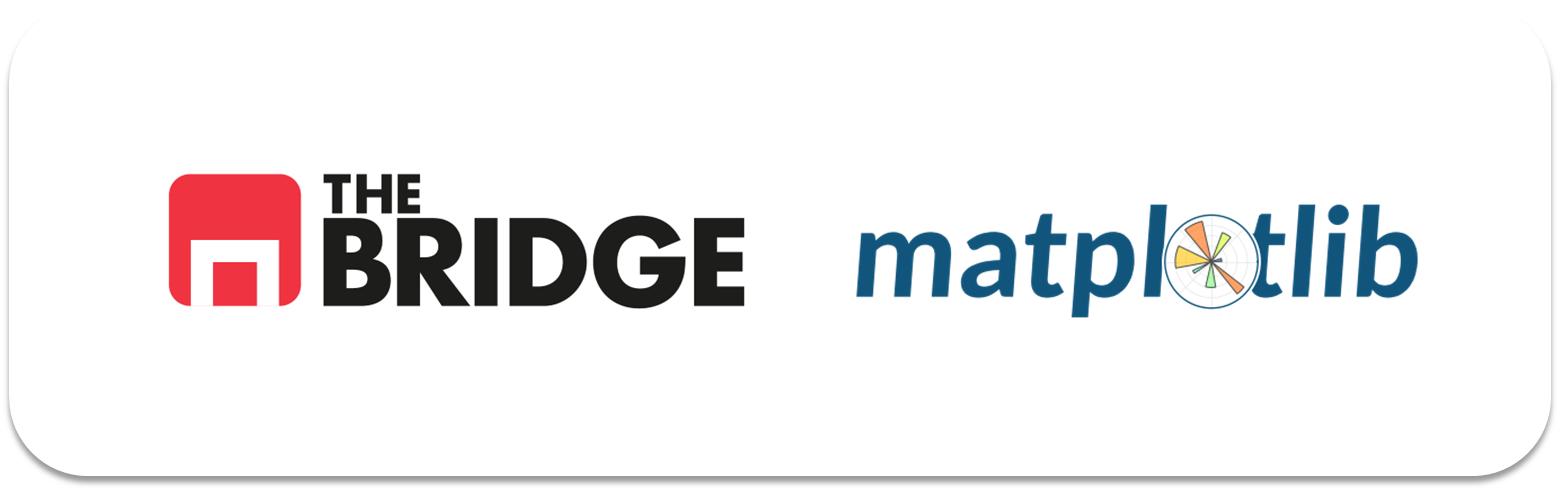

## PRACTICA OBLIGATORIA: **Visualización Básica**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de construcción de gráficas. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Ejercicio 1

#### #1.1

- Carga el dataset de casas de California que está en la ruta "./data/california_cities.csv".  
- Muestra parte de su contenido y su descripción.  
- Deshazte de las filas con nulos.

In [2]:
df = pd.read_csv("./data/california_cities.csv")

In [3]:
df = df.dropna()

In [4]:
df.head()

,Unnamed: 0,city,latd,longd,elevation_m,elevation_ft,population_total,area_total_sq_mi,area_land_sq_mi,area_water_sq_mi,area_total_km2,area_land_km2,area_water_km2,area_water_percent
0,0,Adelanto,34.576111,-117.432778,875.0,2871.0,31765,56.027,56.009,0.018,145.107,145.062,0.046,0.03
1,1,AgouraHills,34.153333,-118.761667,281.0,922.0,20330,7.822,7.793,0.029,20.260,20.184,0.076,0.37
4,4,Alhambra,34.081944,-118.135000,150.0,492.0,83089,7.632,7.631,0.001,19.766,19.763,0.003,0.01
5,5,AlisoViejo,33.575000,-117.725556,127.0,417.0,47823,7.472,7.472,0.000,19.352,19.352,0.000,0.00
6,6,Alturas,41.487222,-120.542500,1332.0,4370.0,2827,2.449,2.435,0.014,6.342,6.306,0.036,0.57


In [5]:
df.info()

<class 'pandas.DataFrame'>
Index: 427 entries, 0 to 481
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          427 non-null    int64  
 1   city                427 non-null    str    
 2   latd                427 non-null    float64
 3   longd               427 non-null    float64
 4   elevation_m         427 non-null    float64
 5   elevation_ft        427 non-null    float64
 6   population_total    427 non-null    int64  
 7   area_total_sq_mi    427 non-null    float64
 8   area_land_sq_mi     427 non-null    float64
 9   area_water_sq_mi    427 non-null    float64
 10  area_total_km2      427 non-null    float64
 11  area_land_km2       427 non-null    float64
 12  area_water_km2      427 non-null    float64
 13  area_water_percent  427 non-null    float64
dtypes: float64(11), int64(2), str(1)
memory usage: 50.0 KB


In [13]:
df.area_land_sq_mi.value_counts()

area_land_sq_mi
7.931     2
1.350     2
1.148     2
56.009    1
7.793     1
         ..
1.531     1
9.980     1
14.578    1
27.888    1
40.015    1
Name: count, Length: 424, dtype: int64

#### #1.2  

Recrea la siguiente figura, para ello construye en apartados separados cada gráfico y luego haz un apartado en el que se junten los cuatro.  

Las figuras son:
1. Las ciudades más pobladas, con los numeros de las poblaciones (tendrás que usar texto y recordar que para centrarlos se necesita poner el argumento `ha` a "center" o investigar como funciona bar_label). Los colores de las barras deben tener un 50% de transparencia y ser: azul, gris, rojo, aceituna y marrón.  

2. Histograma del área total ocupada por las ciudades. (50 bins, fuente = "Arial", tamaño = 14, peso = "Bold", color azul acero o "steelblue")
3. El scatter de área de agua de un ciudad con su poblacion. Transparencia al 50% y color verde.
4. El boxplot de la altura de las ciudades.

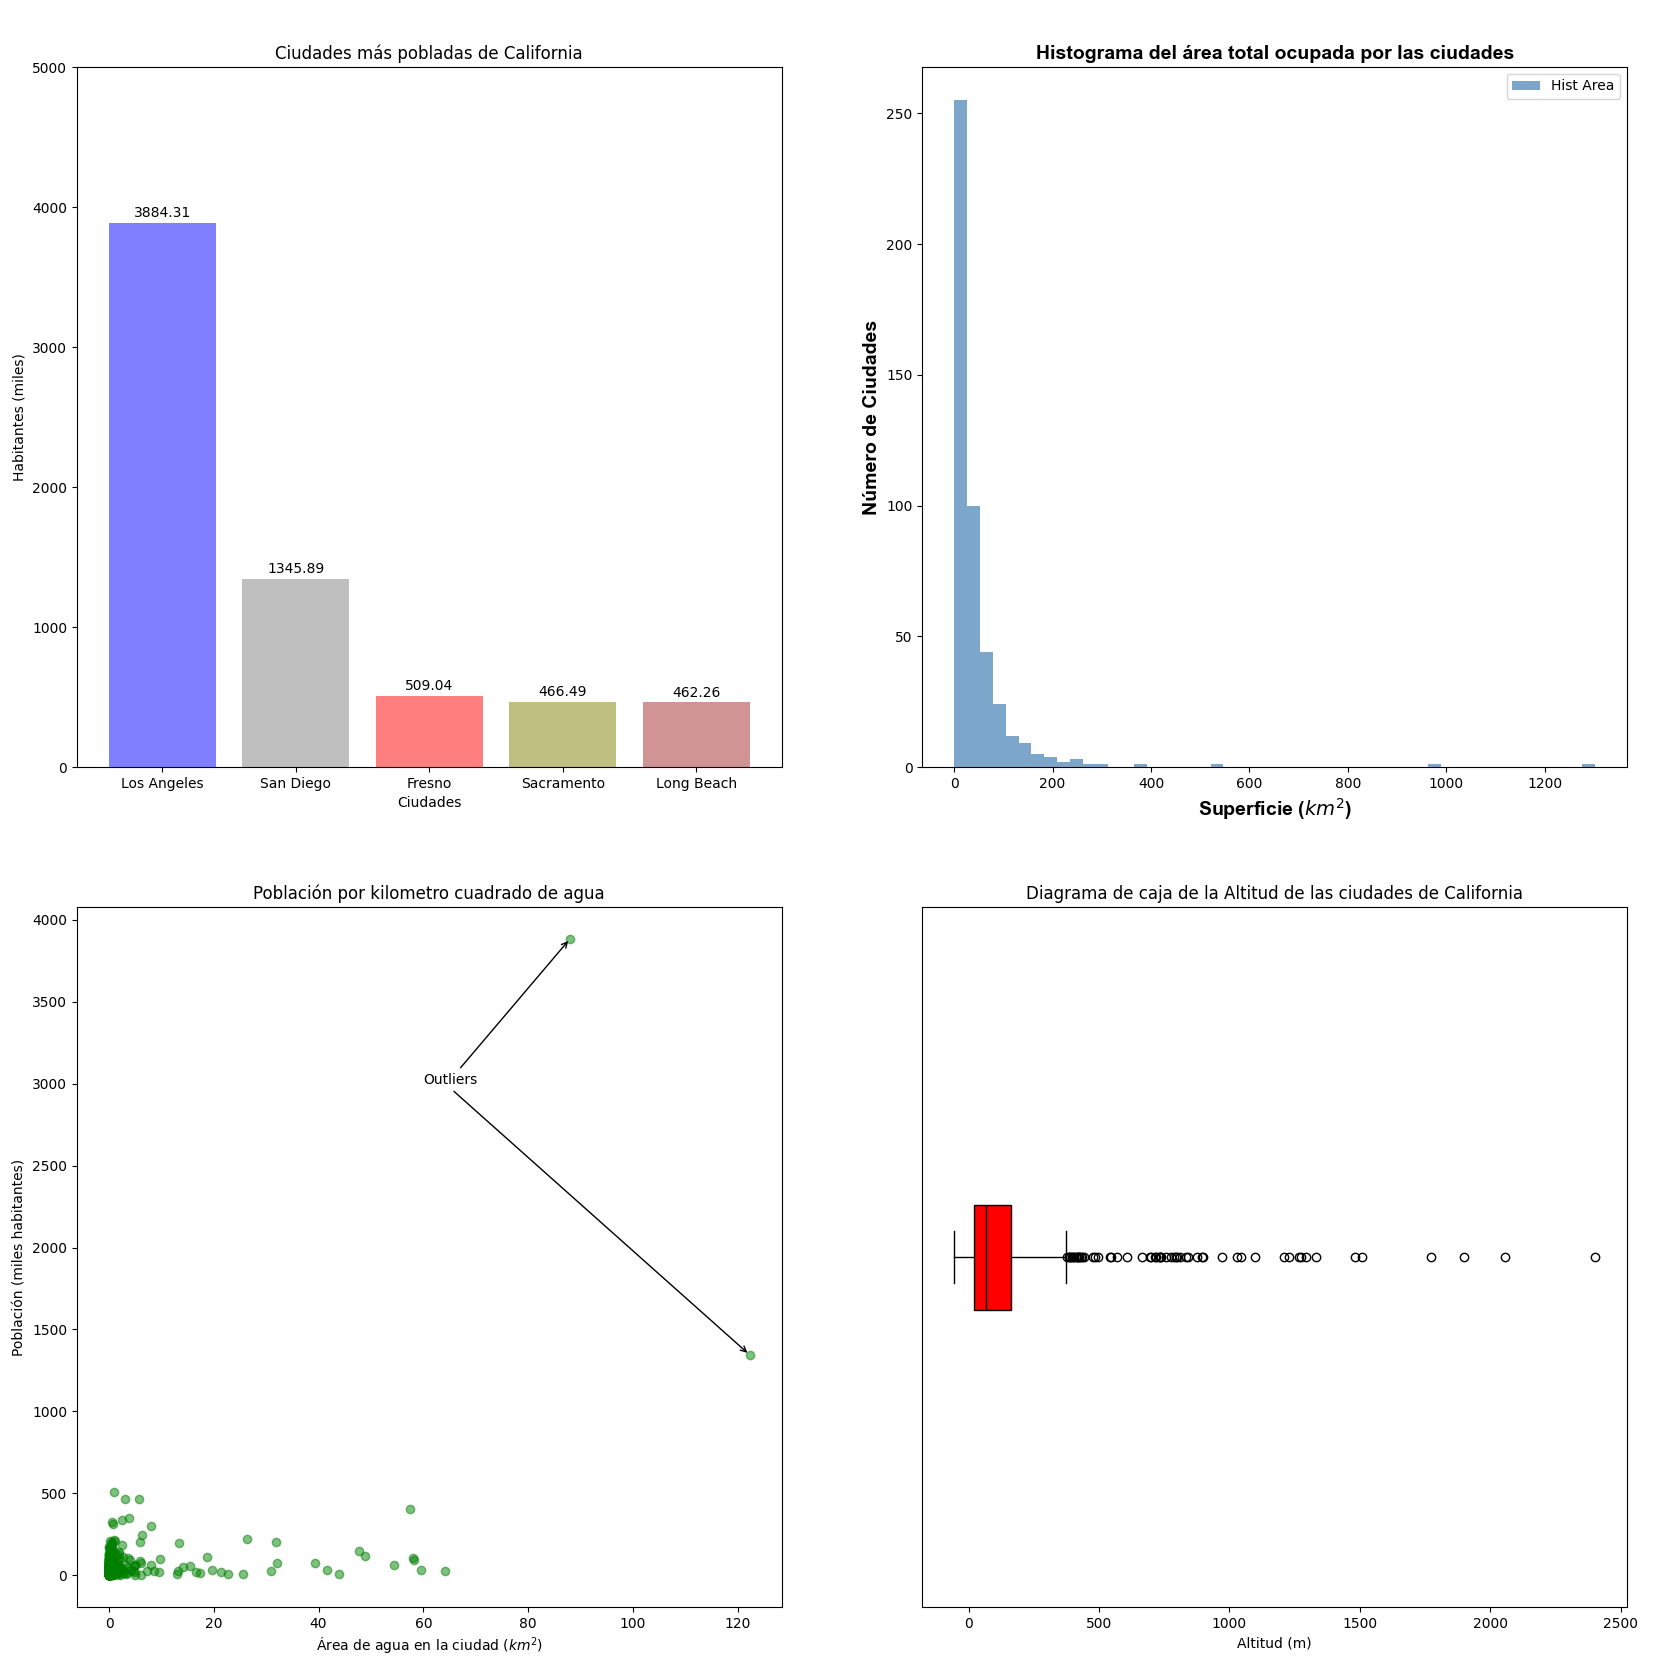

Gráfico 1

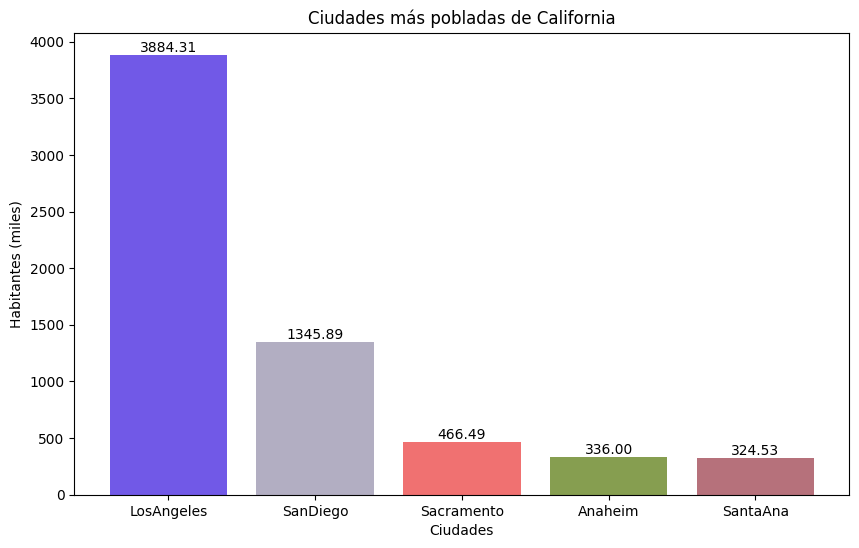

In [22]:
# Seleccionar las 5 ciudades más pobladas
top_5 = df.sort_values(
    "population_total",
    ascending=False
).head(5).copy()

# Convertir población a miles de habitantes
top_5["population_thousands"] = top_5["population_total"] / 1000

# Crear la gráfica
plt.figure(figsize=(10, 6))

bars = plt.bar(
    top_5["city"],
    top_5["population_thousands"],
    color=["#6D54E7F8", "#B0ACC1F8","#F06D6DF8", "#839B4BF8", "#B46D77F8" ]
)

plt.title("Ciudades más pobladas de California")
plt.xlabel("Ciudades")
plt.ylabel("Habitantes (miles)")

# Añadir los valores encima de las barras
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig("grafico1.png")
plt.show()

Gráfico 2

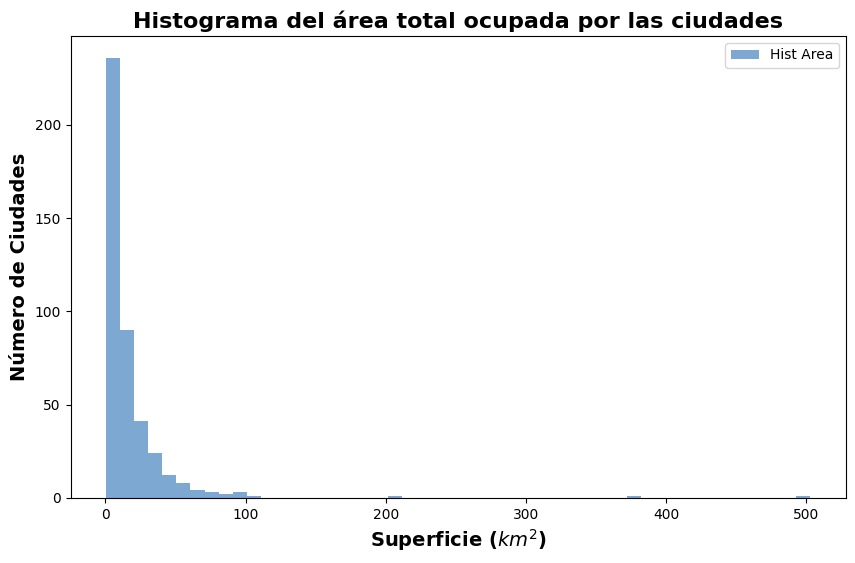

In [23]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["area_total_sq_mi"],
    bins=50,
    label="Hist Area",
    color="#79A6D1F8"
)

plt.title(
    "Histograma del área total ocupada por las ciudades",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Superficie ($km^2$)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Número de Ciudades",
    fontsize=14,
    fontweight="bold"
)

plt.legend()

plt.savefig("grafico2.png")
plt.show()

Gráfico 3

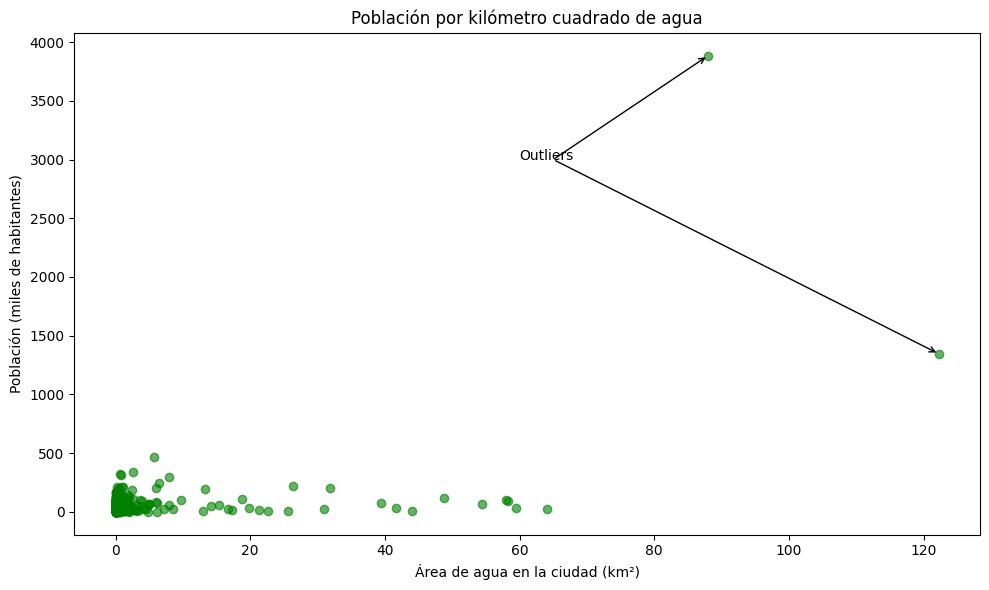

In [24]:
plt.figure(figsize=(10, 6))

x = df["area_water_km2"]
y = df["population_total"] / 1000

plt.scatter(x, y, color="green", alpha=0.6)

# Buscar los dos valores más altos de población
outliers = df.nlargest(2, "population_total")

for _, fila in outliers.iterrows():
    plt.annotate(
        "",
        xy=(fila["area_water_km2"], fila["population_total"] / 1000),
        xytext=(65, 3000),
        arrowprops=dict(arrowstyle="->", color="black")
    )

plt.text(60, 3000, "Outliers")

plt.title("Población por kilómetro cuadrado de agua")
plt.xlabel("Área de agua en la ciudad (km²)")
plt.ylabel("Población (miles de habitantes)")

plt.savefig("grafico3.png")
plt.tight_layout()
plt.show()

Gráfico 4

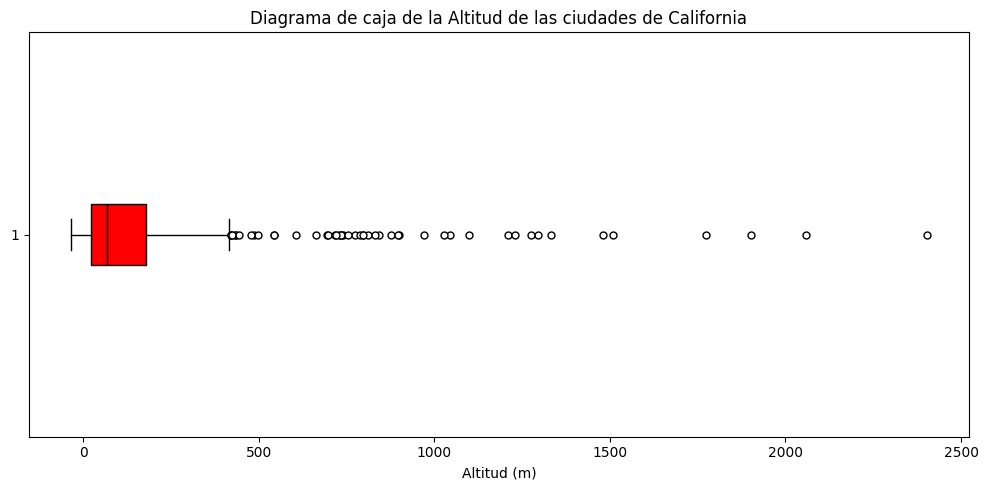

In [25]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["elevation_m"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="red"),
    medianprops=dict(color="black"),
    flierprops=dict(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=5
    )
)

plt.title("Diagrama de caja de la Altitud de las ciudades de California")
plt.xlabel("Altitud (m)")

plt.tight_layout()
plt.savefig("grafico4.png")
plt.show()


#### #1.3

Graba la figura en un archivo .png y sube el archivo a tu repositorio personal junto con el notebook.

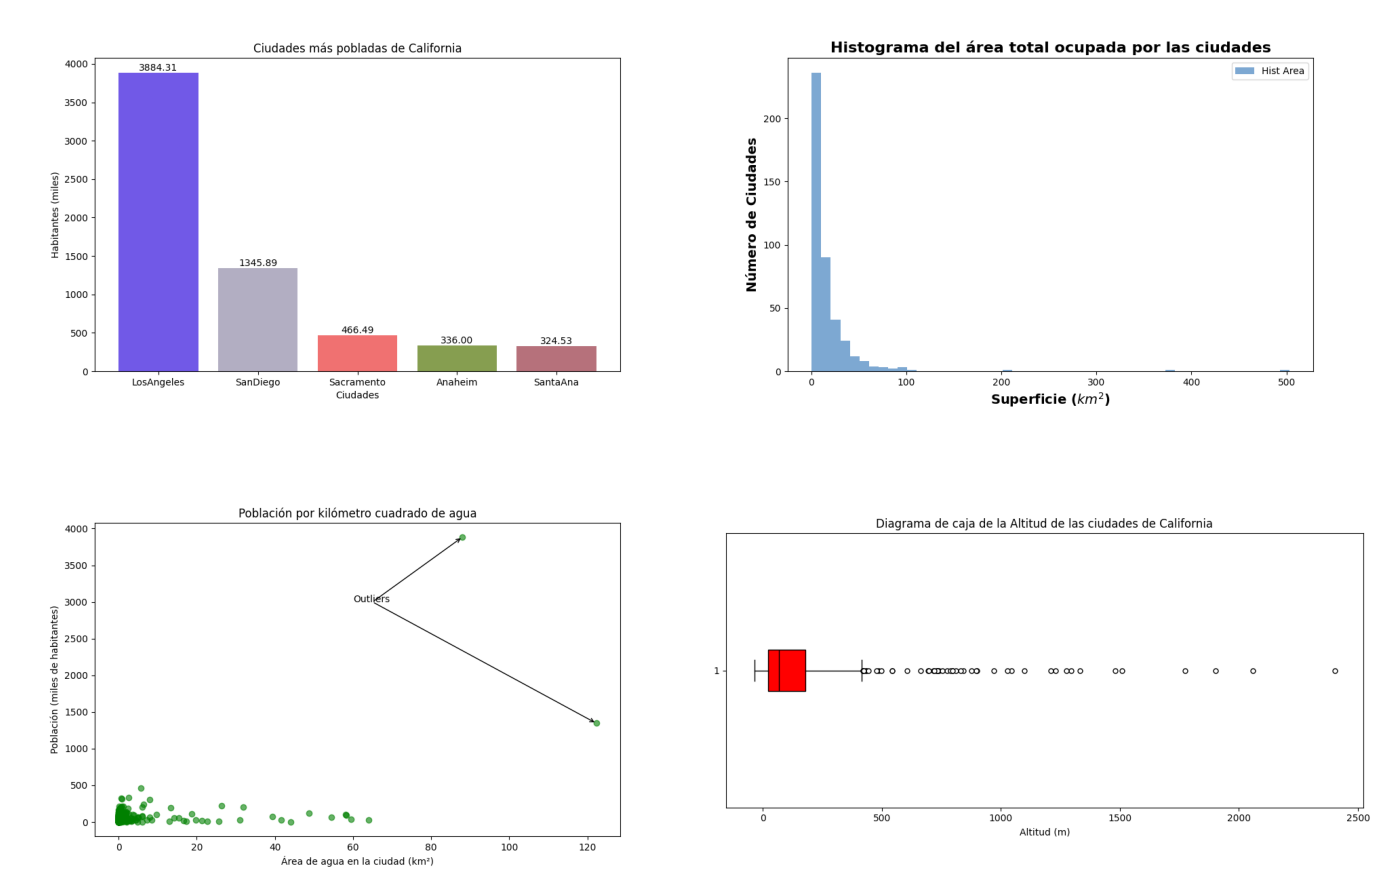

In [27]:
import matplotlib.image as mpimg

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

imagenes = [
    "grafico1.png",
    "grafico2.png",
    "grafico3.png",
    "grafico4.png"
]

for ax, imagen in zip(axs.flat, imagenes):
    ax.imshow(mpimg.imread(imagen))
    ax.axis("off")

plt.tight_layout()
plt.savefig("grafico_completo.png")
plt.show()